# 📅 Chapter 4: Working with Dates & Times in Pandas
**Course: Working with Dates and Times in Python — DataCamp**

---
## 📚 Topics Covered
1. Reading date/time data into Pandas
2. Timezone-aware arithmetic
3. Summarizing datetime data
4. Resampling by time period
5. Timezones in Pandas
6. Other datetime methods (`.dt` accessor)
7. Shifting data with `.shift()`

---
## 🔑 Key Concept Summary

| Concept | Method/Tool | Example |
|---|---|---|
| Load datetime columns | `parse_dates=[]` or `pd.to_datetime()` | `pd.read_csv('file.csv', parse_dates=['Start date'])` |
| Calculate duration | Subtract two datetime columns | `rides['End date'] - rides['Start date']` |
| Convert to seconds | `.dt.total_seconds()` | `rides['Duration'].dt.total_seconds()` |
| Aggregate per group | `.groupby().mean()` | `rides.groupby('Member type')['Duration seconds'].mean()` |
| Resample by time period | `.resample('ME')` | `rides.resample('ME', on='Start date').mean()` |
| Set timezone | `.dt.tz_localize()` | `rides['Start date'].dt.tz_localize('America/New_York')` |
| Convert timezone | `.dt.tz_convert()` | `col.dt.tz_convert('UTC')` |
| Extract year/weekday | `.dt.year`, `.dt.day_name()` | `rides['Start date'].dt.year` |
| Shift rows | `.shift(n)` | `rides['End date'].shift(1)` |

---
## 📦 Setup — Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
import matplotlib.pyplot as plt

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 📖 Section 1: Reading Date/Time Data in Pandas

### Method 1: `parse_dates` argument in `read_csv()`
Pandas can automatically parse date columns when loading a CSV.

In [2]:
# ── Create a sample dataset (simulating capital-onebike.csv) ──
data = {
    'Start date': ['2017-10-01 15:23:25', '2017-10-01 15:42:57',
                   '2017-10-02 06:37:10', '2017-10-03 08:00:00',
                   '2017-11-05 09:30:00'],
    'End date':   ['2017-10-01 15:26:26', '2017-10-01 17:49:59',
                   '2017-10-02 06:42:53', '2017-10-03 08:21:18',
                   '2017-11-05 10:00:00'],
    'Start station': ['Glebe Rd & 11th St N', 'George Mason Dr & Wilson Blvd',
                      'George Mason Dr & Wilson Blvd', 'Main St & 1st Ave',
                      '6th & H St NE'],
    'End station':   ['George Mason Dr & Wilson Blvd', 'George Mason Dr & Wilson Blvd',
                      'Ballston Metro / N Stuart & 9th St N', 'Central Park',
                      '3rd & M St NE'],
    'Bike number': ['W20529'] * 5,
    'Member type': ['Member', 'Casual', 'Member', 'Member', 'Casual']
}

# Method 1: parse_dates when reading CSV (simulated here with pd.DataFrame + to_datetime)
rides = pd.DataFrame(data)
rides['Start date'] = pd.to_datetime(rides['Start date'], format='%Y-%m-%d %H:%M:%S')
rides['End date']   = pd.to_datetime(rides['End date'],   format='%Y-%m-%d %H:%M:%S')

print(rides.head(3))
print('\nDtype of Start date:', rides['Start date'].dtype)

           Start date            End date                  Start station  \
0 2017-10-01 15:23:25 2017-10-01 15:26:26           Glebe Rd & 11th St N   
1 2017-10-01 15:42:57 2017-10-01 17:49:59  George Mason Dr & Wilson Blvd   
2 2017-10-02 06:37:10 2017-10-02 06:42:53  George Mason Dr & Wilson Blvd   

                            End station Bike number Member type  
0         George Mason Dr & Wilson Blvd      W20529      Member  
1         George Mason Dr & Wilson Blvd      W20529      Casual  
2  Ballston Metro / N Stuart & 9th St N      W20529      Member  

Dtype of Start date: datetime64[ns]


In [3]:
# Method 2: Using parse_dates in read_csv (shown for reference)
# rides = pd.read_csv('capital-onebike.csv',
#                     parse_dates=['Start date', 'End date'])

# After parsing, individual values are Timestamps:
print('Row 2 Start date:', rides['Start date'].iloc[2])
print('Type:', type(rides['Start date'].iloc[2]))

Row 2 Start date: 2017-10-02 06:37:10
Type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>


---
## ⏱️ Section 2: Timezone-Aware Arithmetic — Creating a Duration Column

In [4]:
# Subtract start from end to get timedelta
rides['Duration'] = rides['End date'] - rides['Start date']

print('Duration column (timedelta):')  
print(rides['Duration'])
print('\nDtype:', rides['Duration'].dtype)

Duration column (timedelta):
0   0 days 00:03:01
1   0 days 02:07:02
2   0 days 00:05:43
3   0 days 00:21:18
4   0 days 00:30:00
Name: Duration, dtype: timedelta64[ns]

Dtype: timedelta64[ns]


In [5]:
# Convert duration to total seconds (float)
rides['Duration seconds'] = rides['Duration'].dt.total_seconds()

print('Duration in seconds:')
print(rides['Duration seconds'])

Duration in seconds:
0     181.0
1    7622.0
2     343.0
3    1278.0
4    1800.0
Name: Duration seconds, dtype: float64


---
## 📊 Section 3: Summarizing Datetime Data

In [6]:
# Average ride duration
print('Average duration:', rides['Duration'].mean())

# Total ride duration  
print('Total duration: ', rides['Duration'].sum())

Average duration: 0 days 00:37:24.800000
Total duration:  0 days 03:07:04


In [7]:
# Percent of time out of the dock (out of 91 days = Q4 2017)
pct = rides['Duration'].sum() / timedelta(days=91)
print(f'Percent of time in use: {pct:.4%}')

Percent of time in use: 0.1428%


In [8]:
# Count by member type
print('Ride counts by member type:')
print(rides['Member type'].value_counts())

print('\nPercent of rides by member type:')
print(rides['Member type'].value_counts() / len(rides))

Ride counts by member type:
Member    3
Casual    2
Name: Member type, dtype: int64

Percent of rides by member type:
Member    0.6
Casual    0.4
Name: Member type, dtype: float64


In [9]:
# Average duration per member type using groupby
print('Average duration (seconds) per member type:')
print(rides.groupby('Member type')['Duration seconds'].mean())

print('\nGroup size:')
print(rides.groupby('Member type').size())

print('\nFirst ride per group:')
print(rides.groupby('Member type').first()[['Duration']])

Average duration (seconds) per member type:
Member type
Casual    4711.000000
Member     600.666667
Name: Duration seconds, dtype: float64

Group size:
Member type
Casual    2
Member    3
dtype: int64

First ride per group:
                   Duration
Member type                
Casual      0 days 02:07:02
Member      0 days 00:03:01


---
## 📆 Section 4: Resampling by Time Period

`.resample()` groups rows based on a datetime column — like `groupby()` for time periods.

| Frequency Code | Meaning |
|---|---|
| `'D'` | Daily |
| `'W'` | Weekly |
| `'ME'` | Month End |
| `'YE'` | Year End |

In [10]:
# Average duration per month
monthly = rides.resample('ME', on='Start date')['Duration seconds'].mean()
print('Average duration by month:')
print(monthly)

ValueError: Invalid frequency: ME

In [11]:
# Plot monthly averages
rides.resample('ME', on='Start date')['Duration seconds'].mean().plot(
    title='Average Ride Duration by Month',
    ylabel='Seconds',
    marker='o'
)
plt.tight_layout()
plt.show()

ValueError: Invalid frequency: ME

In [12]:
# Daily resample
daily = rides.resample('D', on='Start date')['Duration seconds'].mean()
print('Average duration by day:')
print(daily)

Average duration by day:
Start date
2017-10-01    3901.5
2017-10-02     343.0
2017-10-03    1278.0
2017-10-04       NaN
2017-10-05       NaN
2017-10-06       NaN
2017-10-07       NaN
2017-10-08       NaN
2017-10-09       NaN
2017-10-10       NaN
2017-10-11       NaN
2017-10-12       NaN
2017-10-13       NaN
2017-10-14       NaN
2017-10-15       NaN
2017-10-16       NaN
2017-10-17       NaN
2017-10-18       NaN
2017-10-19       NaN
2017-10-20       NaN
2017-10-21       NaN
2017-10-22       NaN
2017-10-23       NaN
2017-10-24       NaN
2017-10-25       NaN
2017-10-26       NaN
2017-10-27       NaN
2017-10-28       NaN
2017-10-29       NaN
2017-10-30       NaN
2017-10-31       NaN
2017-11-01       NaN
2017-11-02       NaN
2017-11-03       NaN
2017-11-04       NaN
2017-11-05    1800.0
Freq: D, Name: Duration seconds, dtype: float64


---
## 🌍 Section 5: Timezones in Pandas

- **`tz_localize()`** — assigns a timezone to timezone-naive datetimes (keeps the clock the same)
- **`tz_convert()`** — converts timezone-aware datetimes to a different timezone (shifts the clock)
- **`ambiguous='NaT'`** — handles DST ambiguous times by setting them to Not a Time

In [13]:
# Localize to Eastern Time (handles DST with ambiguous='NaT')
rides['Start date'] = rides['Start date'].dt.tz_localize('America/New_York', ambiguous='NaT')
rides['End date']   = rides['End date'].dt.tz_localize('America/New_York', ambiguous='NaT')

print('Start date after tz_localize:')
print(rides['Start date'].head(3))
print('Dtype:', rides['Start date'].dtype)

Start date after tz_localize:
0   2017-10-01 15:23:25-04:00
1   2017-10-01 15:42:57-04:00
2   2017-10-02 06:37:10-04:00
Name: Start date, dtype: datetime64[ns, America/New_York]
Dtype: datetime64[ns, America/New_York]


In [14]:
# Re-calculate duration after timezone assignment
# (Rows with ambiguous DST times will be NaT, giving NaT duration — expected!)
rides['Duration'] = rides['End date'] - rides['Start date']
rides['Duration seconds'] = rides['Duration'].dt.total_seconds()

# Check for any NaT rows (ambiguous DST times)
print('Rows with NaT duration:')
print(rides[rides['Duration'].isna()])

print('\nMinimum duration (seconds):', rides['Duration seconds'].min())

Rows with NaT duration:
Empty DataFrame
Columns: [Start date, End date, Start station, End station, Bike number, Member type, Duration, Duration seconds]
Index: []

Minimum duration (seconds): 181.0


---
## 🔧 Section 6: Other `.dt` Accessor Methods

In [15]:
# Extract the year
print('Year of first 3 rides:')
print(rides['Start date'].head(3).dt.year)

# Extract the weekday name
print('\nWeekday of first 3 rides:')
print(rides['Start date'].head(3).dt.day_name())

Year of first 3 rides:
0    2017
1    2017
2    2017
Name: Start date, dtype: int64

Weekday of first 3 rides:
0    Sunday
1    Sunday
2    Monday
Name: Start date, dtype: object


In [16]:
# Other useful .dt attributes
print('Month:', rides['Start date'].head(3).dt.month.values)
print('Day:  ', rides['Start date'].head(3).dt.day.values)
print('Hour: ', rides['Start date'].head(3).dt.hour.values)

Month: [10 10 10]
Day:   [1 1 2]
Hour:  [15 15  6]


---
## ↔️ Section 7: Shifting Data with `.shift()`

In [17]:
# Shift the End date column forward by 1 row (padding first row with NaT)
shifted = rides['End date'].shift(1)
print('End date shifted forward by 1:')
print(shifted.head(3))

End date shifted forward by 1:
0                         NaT
1   2017-10-01 15:26:26-04:00
2   2017-10-01 17:49:59-04:00
Name: End date, dtype: datetime64[ns, America/New_York]


In [18]:
# Practical use: calculate time between rides (gap between end of one ride and start of next)
rides['Gap between rides'] = rides['Start date'] - rides['End date'].shift(1)
print('Time gap between consecutive rides:')
print(rides[['Start date', 'Gap between rides']].head())

Time gap between consecutive rides:
                 Start date Gap between rides
0 2017-10-01 15:23:25-04:00               NaT
1 2017-10-01 15:42:57-04:00   0 days 00:16:31
2 2017-10-02 06:37:10-04:00   0 days 12:47:11
3 2017-10-03 08:00:00-04:00   1 days 01:17:07
4 2017-11-05 09:30:00-05:00  33 days 02:08:42


---
## 📋 Section 8: Full Recap

### Recap: Dates and Calendars
- `date()` takes year, month, day as arguments
- Accessors: `.year`, `.month`, `.day`; methods: `.weekday()`
- Use `min()`, `max()`, `sort()` to compare dates
- Subtract dates → `timedelta`
- Convert to string: `.isoformat()` or `.strftime()`

### Recap: Combining Dates and Times
- `datetime()` = `date()` + hour, minute, second, microsecond
- Extra args default to zero
- Replace a value: `.replace()`
- Convert timedelta → int: `.total_seconds()`
- String → datetime: `.strptime()` | datetime → string: `.strftime()`

### Recap: Timezones & Daylight Saving
- Timezone-aware = `tzinfo` is set; timezone-naive = `tzinfo` is None
- `.replace()` → change timezone label (clock stays the same)
- `.astimezone()` → shift clock to match new timezone
- `dateutil.tz` provides a comprehensive timezone database

### Recap: Pandas Datetime Methods
- `parse_dates=[]` in `read_csv()` OR `pd.to_datetime()`
- `.groupby()` → aggregate per group (`.first()`, `.min()`, `.mean()`)
- `.resample()` → group by time period (D, W, ME, YE)
- `.tz_localize()` → set timezone (keeps clock the same)
- `.tz_convert()` → convert timezone (shifts clock)

---
## ✏️ Practice Exercises

Try these on your own!

In [19]:
# Exercise 1: Load a datetime column using pd.to_datetime with the format '%Y-%m-%d %H:%M:%S'
# YOUR CODE HERE
pd.to_datetime(rides['Start date'], format= '%Y-%m-%d %H:%M:%S')

0   2017-10-01 15:23:25-04:00
1   2017-10-01 15:42:57-04:00
2   2017-10-02 06:37:10-04:00
3   2017-10-03 08:00:00-04:00
4   2017-11-05 09:30:00-05:00
Name: Start date, dtype: datetime64[ns, America/New_York]

In [20]:
# Exercise 2: Create a Duration column by subtracting Start date from End date
# Then convert it to total seconds and find the average
# YOUR CODE HERE
rides['Duration'] = rides['End date'] - rides['Start date']
rides['Duration seconds'] = rides['Duration'].dt.total_seconds()

In [21]:
# Exercise 3: Use .groupby('Member type') to find the TOTAL duration in seconds for each group
# YOUR CODE HERE
rides.groupby('Member type')['Duration seconds'].sum()

Member type
Casual    9422.0
Member    1802.0
Name: Duration seconds, dtype: float64

<AxesSubplot:xlabel='Start date'>

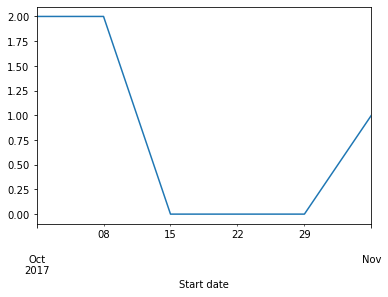

In [22]:
# Exercise 4: Resample rides by week ('W') and plot the count of rides per week
# Hint: use .resample('W', on='Start date').size().plot()
# YOUR CODE HERE
rides.resample('W', on='Start date').size().plot()

<AxesSubplot:xlabel='Start date'>

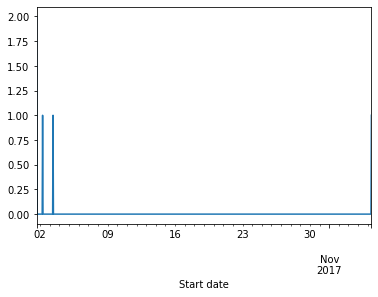

In [23]:
# Exercise 5: Extract the hour of day for each ride's Start date
# Which hour has the most rides?
# YOUR CODE HERE
rides.resample('H', on='Start date').size().plot()